In [1]:
import json 
import math 
from pathlib import Path
from itertools import product

import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import cm 


In [2]:
# Basis states used in tomography
b0 = np.array([1, 0], dtype=complex)                             # |0>
b1 = np.array([0, 1], dtype=complex)                             # |1>
b2 = np.array([1/math.sqrt(2), 1/math.sqrt(2)], dtype=complex)   # |+>
b3 = np.array([1/math.sqrt(2), -1j/math.sqrt(2)], dtype=complex) # |-i>

b = [b0, b1, b2, b3]

# Operator basis: I, X, Y, Z
g0 = np.array([[1, 0], [0, 1]], dtype=complex)
g1 = np.array([[0, 1], [1, 0]], dtype=complex)
g2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
g3 = np.array([[1, 0], [0, -1]], dtype=complex)

g = [g0, g1, g2, g3]

In [3]:
N = 2

b_big = []
g_big = []
structure = []

for combo_indices in product(range(len(b)), repeat=N):
    structure.append(combo_indices)

    result_b = b[combo_indices[0]]
    result_g = g[combo_indices[0]]

    for idx in combo_indices[1:]:
        result_b = np.kron(result_b, b[idx])
        result_g = np.kron(result_g, g[idx])

    b_big.append(result_b)
    g_big.append(result_g)

b_big = np.array(b_big)
g_big = np.array(g_big)

print("b_big shape:", b_big.shape)
print("g_big shape:", g_big.shape)

b_big shape: (16, 4)
g_big shape: (16, 4, 4)


In [4]:
#matrix B and B inverse 
B = np.zeros((b_big.shape[0], b_big.shape[0]), dtype=complex)

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        B[i, j] = np.conjugate(b_big[i]).T @ g_big[j] @ b_big[i]

B_inv = np.linalg.inv(B)

print("B shape:", B.shape)

B shape: (16, 16)


In [5]:
data_dir = Path("../../data/bell_2q_decoherence")

with open(data_dir / "2_counts_64.json", "r", encoding="utf-8") as f:
    all_counts = json.load(f)

print("Number of count dictionaries:", len(all_counts))
print("Example:", all_counts[0])

Number of count dictionaries: 64
Example: {'00': 497, '11': 468, '10': 18, '01': 17}


In [6]:
m_full = np.zeros(len(all_counts), dtype=float)

zero_state = "0" * N

for i in range(len(all_counts)):
    counts = all_counts[i]
    total = sum(counts.values())
    m_full[i] = counts.get(zero_state, 0) / total

print(m_full[:20])

[0.497 0.033 0.248 0.282 0.026 0.502 0.253 0.227 0.265 0.229 0.52  0.249
 0.293 0.271 0.248 0.024 0.522 0.105 0.339 0.297]


In [11]:
A = 3  # 0, 1, 2, 3

time_labels = {
    0: "t = 0 µs",
    1: "t = 4 µs",
    2: "t = 8 µs",
    3: "t = 16 µs",
}

m = np.zeros(len(structure), dtype=float)

for i in range(len(m)):
    m[i] = m_full[i + A * len(m)]

print("Selected block:", A, "|", time_labels[A])
print(m)

Selected block: 3 | t = 16 µs
[0.71  0.13  0.408 0.395 0.121 0.096 0.121 0.098 0.413 0.117 0.245 0.25
 0.377 0.117 0.261 0.249]


In [12]:
rho = np.zeros((2**N, 2**N), dtype=complex)

coeffs = B_inv @ m
for i in range(g_big.shape[0]):
    rho += g_big[i] * coeffs[i]

print("Reconstructed rho:")
print(rho)

Reconstructed rho:
[[ 7.10e-01+0.j     -1.20e-02-0.025j  -2.50e-03-0.0385j -4.00e-02+0.0165j]
 [-1.20e-02+0.025j   1.30e-01+0.j     -5.00e-04+0.011j   4.00e-03+0.004j ]
 [-2.50e-03+0.0385j -5.00e-04-0.011j   1.21e-01+0.j      1.25e-02-0.0105j]
 [-4.00e-02-0.0165j  4.00e-03-0.004j   1.25e-02+0.0105j  9.60e-02+0.j    ]]


In [13]:
print("Trace(rho) =", np.trace(rho))
print("Hermitian check:", np.allclose(rho, rho.conj().T))
evals = np.linalg.eigvals(rho)
print("Eigenvalues:")
print(evals)

Trace(rho) = (1.057+0j)
Hermitian check: True
Eigenvalues:
[0.71688001-5.21437268e-19j 0.08552725-9.29555899e-18j
 0.11473832-1.82082616e-17j 0.13985441+5.47385266e-18j]


C:\Users\igork\AppData\Local\Temp\ipykernel_5792\3899231673.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


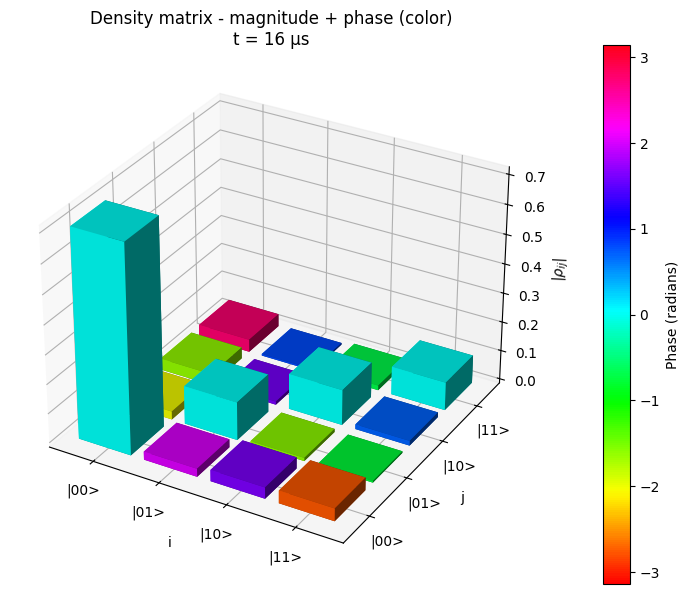

In [15]:
n = rho.shape[0]

x = []
y = []
heights = []
colors = []

for i in range(n):
    for j in range(n):
        x.append(i)
        y.append(j)
        heights.append(np.abs(rho[i, j]))
        colors.append(np.angle(rho[i, j]))

x = np.array(x)
y = np.array(y)
heights = np.array(heights)
colors = np.array(colors)

# Normalize phase from -pi,pi to 0,1 for colormap
norm_colors = (colors + np.pi) / (2 * np.pi)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(
    x, y, np.zeros_like(heights),
    0.8, 0.8, heights,
    color=cm.hsv(norm_colors)
)

labels = [f"|{format(i, f'0{N}b')}>" for i in range(n)]

ax.set_xticks(np.arange(n) + 0.4)
ax.set_xticklabels(labels)

ax.set_yticks(np.arange(n) + 0.4)
ax.set_yticklabels(labels)

ax.set_xlabel("i")
ax.set_ylabel("j")
ax.set_zlabel(r"$|\rho_{ij}|$")
ax.set_title(f"Density matrix - magnitude + phase (color)\n{time_labels[A]}")

sm = plt.cm.ScalarMappable(cmap=cm.hsv, norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.1)
cbar.set_label("Phase (radians)")

plt.tight_layout()
plt.show()